In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "rightway11/state-farm-distracted-driver-detection"
)

print("Dataset path:", path)

Resuming download from 28311552 bytes (518582669 bytes left)...
Resuming download to C:\Users\kara\.cache\kagglehub\datasets\rightway11\state-farm-distracted-driver-detection\1.archive (28311552/546894221) bytes left.


100%|██████████| 522M/522M [03:59<00:00, 2.16MB/s] 

Extracting files...


Dataset path: C:\Users\kara\.cache\kagglehub\datasets\rightway11\state-farm-distracted-driver-detection\versions\1


In [5]:
from imutils import paths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import cv2
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.preprocessing.image import img_to_array
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelBinarizer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2,ResNet50,VGG16,VGG19,EfficientNetV2B0,Xception

In [6]:
path=r"C:\Users\kara\Desktop\DL\driver_dataset"
data_dir = os.path.join(path, "imgs", "train")

classes = sorted(os.listdir(data_dir))

print(classes)
print("Number of classes:", len(classes))

['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of classes: 10


In [7]:
train_path = r"C:\Users\kara\Desktop\DL\driver_dataset\imgs\train"
image_paths = list(paths.list_images(train_path))
print("Number of images:", len(image_paths))
print(image_paths[:5])


class_names = {
    "c0": "Safe driving",
    "c1": "Texting - right hand",
    "c2": "Talking on phone - right hand",
    "c3": "Texting - left hand",
    "c4": "Talking on phone - left hand",
    "c5": "Operating radio",
    "c6": "Drinking",
    "c7": "Reaching behind",
    "c8": "Hair and makeup",
    "c9": "Talking to passenger"
}


def display_image(image_paths, title=None, cols=5, num_images=25):
    image_paths = image_paths.copy()
    random.shuffle(image_paths)
    num_images = min(len(image_paths), num_images)
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(12, 12))
    plt.suptitle(title)

    for i, image_path in enumerate(image_paths[:num_images]):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(image_path)
        plt.imshow(img)
        label = class_names.get(
            os.path.basename(
                os.path.dirname(image_path)))
        plt.title(label)
        plt.axis("off")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Number of images: 17462
['C:\\Users\\kara\\Desktop\\DL\\driver_dataset\\imgs\\train\\c0\\img_100026.jpg', 'C:\\Users\\kara\\Desktop\\DL\\driver_dataset\\imgs\\train\\c0\\img_10003.jpg', 'C:\\Users\\kara\\Desktop\\DL\\driver_dataset\\imgs\\train\\c0\\img_100050.jpg', 'C:\\Users\\kara\\Desktop\\DL\\driver_dataset\\imgs\\train\\c0\\img_100074.jpg', 'C:\\Users\\kara\\Desktop\\DL\\driver_dataset\\imgs\\train\\c0\\img_100145.jpg']


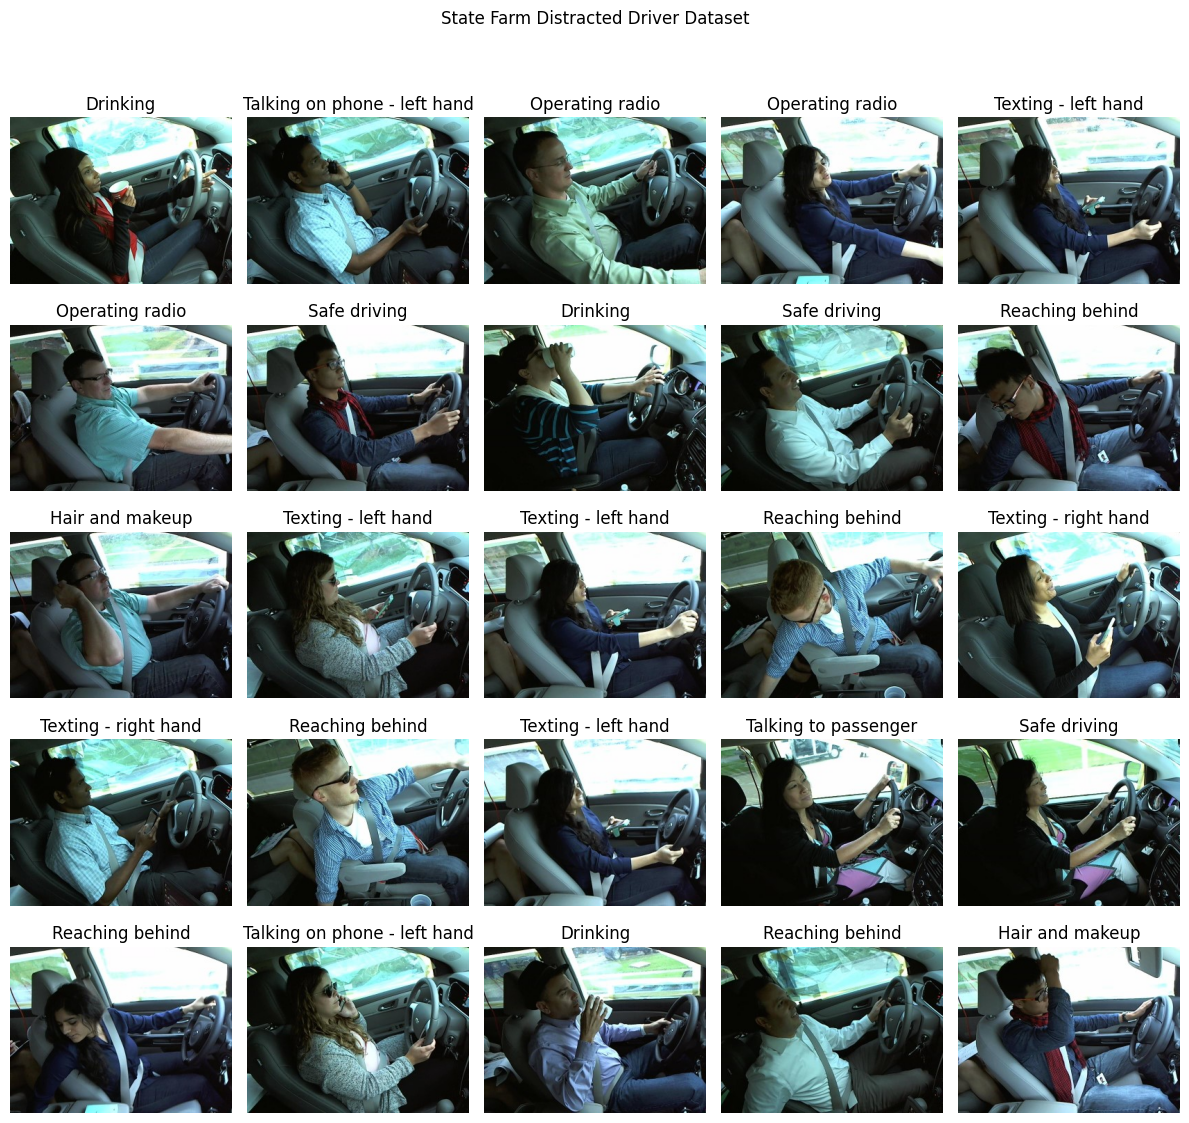

In [8]:
display_image(
    image_paths,
    title="State Farm Distracted Driver Dataset",
    cols=5,
    num_images=25
)

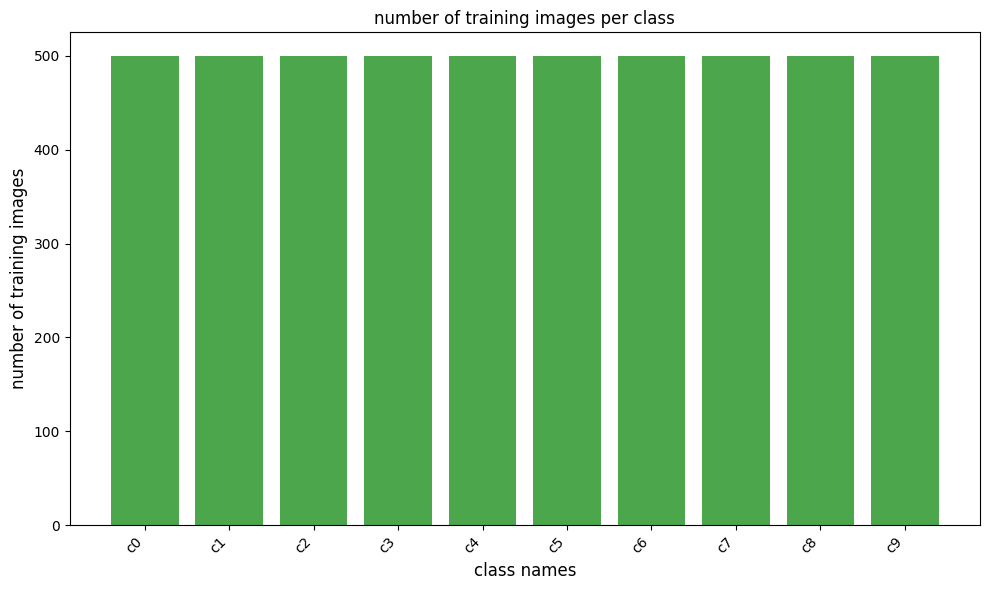

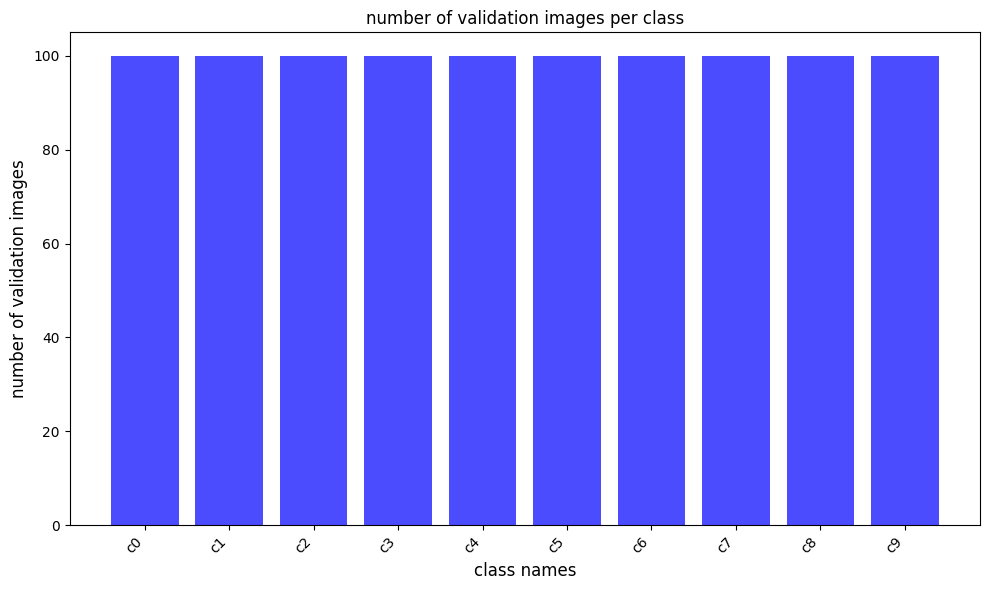

In [9]:
data_folder=r"C:\Users\kara\Desktop\DL\driver_dataset\imgs\train"

train_counts = 500
val_counts = 100
train_pathh={cls:[]for cls in os.listdir(data_folder)}
val_path = {cls:[]for cls in os.listdir(data_folder)}

for cls in train_pathh.keys():
    class_folder = os.path.join(data_folder,cls)
    if os.path.isdir(class_folder):

        images = [os.path.join(class_folder,img)for img in os.listdir(class_folder)if img.endswith(('.png','.jpg','.jpeg'))]
        random.shuffle(images)
        train_pathh[cls] = images[:train_counts]
        val_path[cls]=images[train_counts:train_counts+val_counts]

train_counts={cls:len(paths) for cls,paths in train_pathh.items()}
val_counts = {cls:len(paths)for cls,paths in val_path.items()}

plt.figure(figsize=(10,6))
plt.bar(train_counts.keys(),train_counts.values(),color='green',alpha=0.7)
plt.xlabel("class names",fontsize=12)
plt.ylabel("number of training images",fontsize=12)
plt.title("number of training images per class",fontsize=12)
plt.xticks(rotation=45,ha="right",fontsize=10)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))
plt.bar(val_counts.keys(),val_counts.values(),color='blue',alpha=0.7)
plt.xlabel("class names",fontsize=12)
plt.ylabel("number of validation images",fontsize=12)
plt.title("number of validation images per class",fontsize=12)
plt.xticks(rotation=45,ha="right",fontsize=10)
plt.tight_layout()
plt.show()


In [10]:
import os
import cv2
import numpy as np

class SimpleDatasetLoader:

    def __init__(self, preprocessors=None):
        self.preprocessors = preprocessors or []

    def load(self, image_paths, verbose=0):

        data = []
        labels = []

        for i, image_path in enumerate(image_paths):

            # خواندن تصویر
            image = cv2.imread(image_path)

            # بررسی اینکه تصویر درست خوانده شده
            if image is None:
                print(f"[WARNING] Could not read image: {image_path}")
                continue

            # BGR → RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # اعمال preprocessing
            for preprocessor in self.preprocessors:
                image = preprocessor.preprocess(image)

            # استخراج label از نام پوشه
            label = os.path.basename(
                os.path.dirname(image_path)
            )

            data.append(image)
            labels.append(label)

            if verbose > 0 and (i + 1) % verbose == 0:
                print(
                    f"[INFO] Processed "
                    f"{i + 1}/{len(image_paths)}"
                )

        return np.array(data), np.array(labels)

In [11]:
class SimplePreprocessor:
    def __init__(self,width,height,inter=cv2.INTER_AREA):
        self.width=width
        self.height=height
        self.inter=inter

    def preprocess(self,image):
        return cv2.resize(image,(self.width,self.height),interpolation=self.inter)

In [12]:
class ImageToArrayPreprocessor:
    def __init__(self,dataformat=None):
        self.dataformat=dataformat
    def preprocess(self,image):
        return img_to_array(image,data_format=self.dataformat)

In [13]:
sp=SimplePreprocessor(128,128)
inp=ImageToArrayPreprocessor()

In [14]:
all_train_paths = [
    image_path
    for class_paths in train_pathh.values()
    for image_path in class_paths
]

all_val_paths = [
    image_path
    for class_paths in val_path.values()
    for image_path in class_paths
]
print(f"total training: {len(all_train_paths)}")
print(f"total validation: {len(all_val_paths)}")

total training: 5000
total validation: 1000


In [15]:
sql = SimpleDatasetLoader(preprocessors=[sp,inp])
(train_data,train_labels)=sql.load(all_train_paths,verbose=1000)

[INFO] Processed 1000/5000
[INFO] Processed 2000/5000
[INFO] Processed 3000/5000
[INFO] Processed 4000/5000
[INFO] Processed 5000/5000


In [16]:
sql = SimpleDatasetLoader(preprocessors=[sp,inp])
(val_data,val_labels)=sql.load(all_val_paths,verbose=500)

[INFO] Processed 500/1000
[INFO] Processed 1000/1000


In [17]:
train_scale_data=train_data.astype('float32')/255
val_sclae_data = val_data.astype('float32')/255


In [18]:
import os
import numpy as np

save_dir = r"C:\Users\kara\Desktop\DL\driver_dataset\numpy_data"
os.makedirs(save_dir, exist_ok=True)
np.save(
    os.path.join(save_dir, "train_data.npy"),
    train_data
)

np.save(
    os.path.join(save_dir, "train_labels.npy"),
    train_labels
)

np.save(
    os.path.join(save_dir, "val_data.npy"),
    val_data
)

np.save(
    os.path.join(save_dir, "val_labels.npy"),
    val_labels
)

In [19]:
import numpy as np
import os

save_dir = r"C:\Users\kara\Desktop\DL\driver_dataset\numpy_data"

train_scale_data = np.load(
    os.path.join(save_dir, "train_data.npy")
)

train_labels = np.load(
    os.path.join(save_dir, "train_labels.npy")
)

val_sclae_data = np.load(
    os.path.join(save_dir, "val_data.npy")
)

val_labels = np.load(
    os.path.join(save_dir, "val_labels.npy")
)

In [20]:
train_val_data={'total data':[len(train_scale_data),len(val_sclae_data),len(train_labels),len(val_labels)]}
pd.DataFrame.from_dict(train_val_data,orient='index',columns=["train_scale_data","train_labels","val_sclae_data","val_labels"])

,train_scale_data,train_labels,val_sclae_data,val_labels
total data,5000,1000,5000,1000


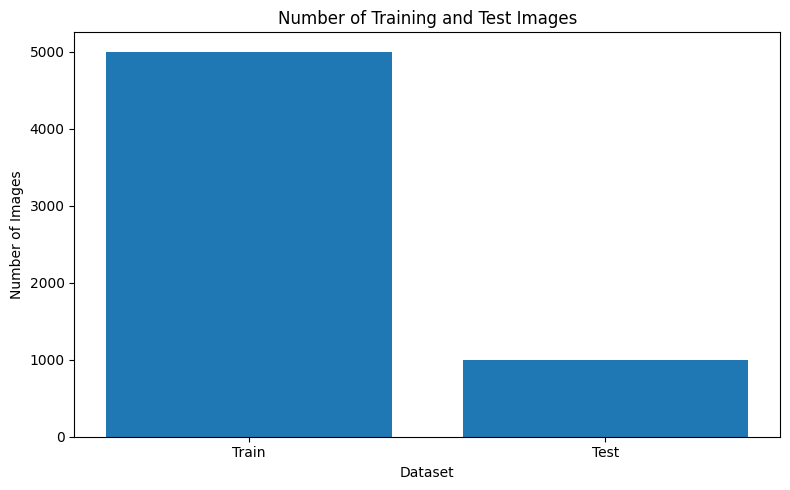

In [21]:
import matplotlib.pyplot as plt

num_train_images = len(train_scale_data)
num_test_images = len(val_sclae_data)

labels = ["Train", "Test"]
counts = [num_train_images, num_test_images]

plt.figure(figsize=(8, 5))

plt.bar(labels, counts)

plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.title("Number of Training and Test Images")

plt.tight_layout()
plt.show()

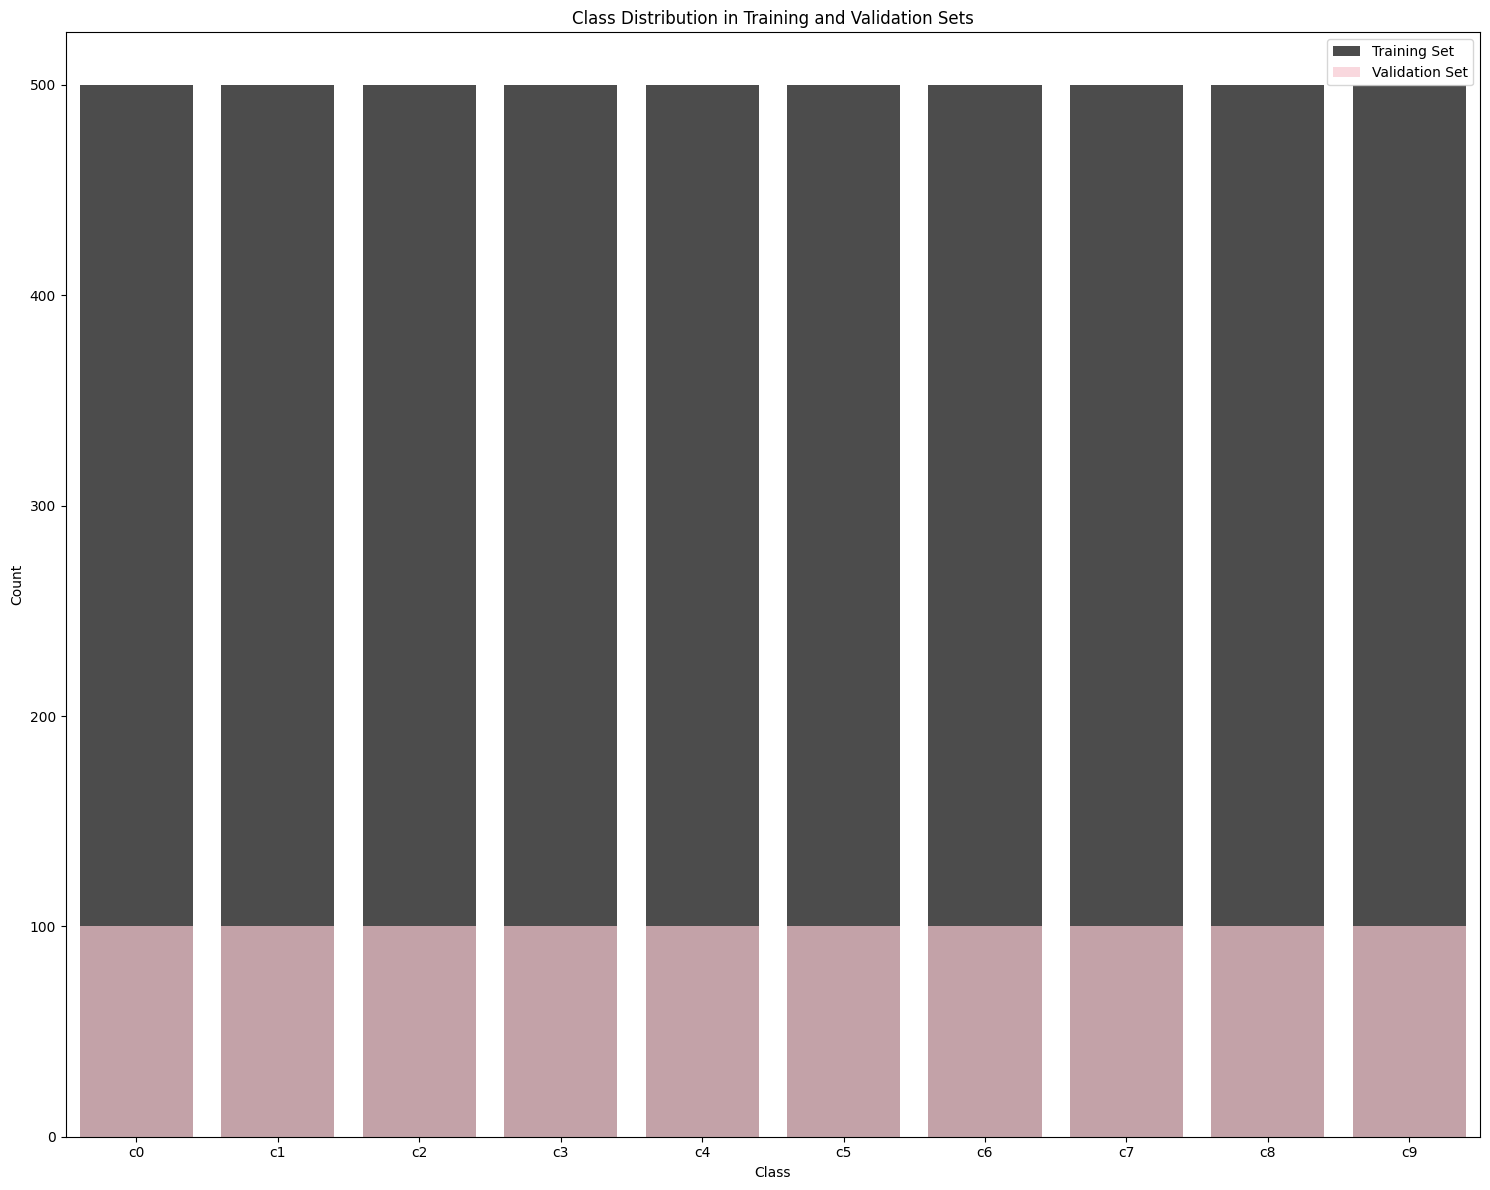

In [22]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

train_data = pd.DataFrame({
    "Class": train_labels
})

val_data = pd.DataFrame({
    "Class": val_labels
})

plt.figure(figsize=(15, 12))

sns.countplot(
    x="Class",
    data=train_data,
    color="black",
    alpha=0.7,
    label="Training Set"
)

sns.countplot(
    x="Class",
    data=val_data,
    color="pink",
    alpha=0.7,
    label="Validation Set"
)

plt.title("Class Distribution in Training and Validation Sets")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer()

y_train_label = label_binarizer.fit_transform(train_labels)
y_val_label = label_binarizer.transform(val_labels)

y_train_label = y_train_label.astype("float32")
y_val_label = y_val_label.astype("float32")


In [32]:
import os
import cv2
import numpy as np

test_path = r"C:\Users\kara\Desktop\DL\driver_dataset\imgs\test"

test_files = [
    os.path.join(test_path, f)
    for f in os.listdir(test_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of test images:", len(test_files))

Number of test images: 4961


In [79]:

import random

sample_files = random.sample(test_files, min(20, len(test_files)))

for image_path in sample_files:

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_resized = cv2.resize(image, (128, 128))
    image_array = image_resized.astype("float32")
    image_array = np.expand_dims(image_array, axis=0)

    prediction = test_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(prediction[0])
    confidence = prediction[0][predicted_index]

    predicted_class = label_binarizer.classes_[predicted_index]

    print(
        os.path.basename(image_path),
        "→",
        predicted_class,
        "→",
        class_names[predicted_class],
        f"({confidence * 100:.1f}%)"
    )

img_67218.jpg → c4 → Talking on phone - left hand (71.1%)
img_394.jpg → c7 → Reaching behind (97.8%)
img_39268.jpg → c4 → Talking on phone - left hand (67.5%)
img_54415.jpg → c0 → Safe driving (96.5%)
img_95596.jpg → c0 → Safe driving (55.3%)
img_72540.jpg → c4 → Talking on phone - left hand (97.8%)
img_40633.jpg → c7 → Reaching behind (82.6%)
img_39754.jpg → c5 → Operating radio (99.0%)
img_26130.jpg → c8 → Hair and makeup (92.4%)
img_39526.jpg → c3 → Texting - left hand (92.6%)
img_29561.jpg → c0 → Safe driving (53.6%)
img_8744.jpg → c8 → Hair and makeup (96.5%)
img_14363.jpg → c1 → Texting - right hand (44.1%)
img_52060.jpg → c8 → Hair and makeup (95.2%)
img_90389.jpg → c8 → Hair and makeup (84.2%)
img_94297.jpg → c9 → Talking to passenger (48.5%)
img_68842.jpg → c6 → Drinking (65.4%)
img_38701.jpg → c8 → Hair and makeup (39.6%)
img_9843.jpg → c4 → Talking on phone - left hand (97.7%)
img_13664.jpg → c9 → Talking to passenger (76.8%)


In [20]:
def build_efficientnet(
    input_shape=(128, 128, 3),
    num_classes=10,
    weights_path=None
):
    
    # Input
    inputs = keras.Input(shape=input_shape)

    # EfficientNet backbone
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=None,
        input_tensor=inputs
    )

    # Load ImageNet weights
    if weights_path is not None:
        base_model.load_weights(weights_path)

    # Freeze backbone
    base_model.trainable = False

    # Classification head
    x = base_model.output

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    # Complete model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    return model, base_model

In [21]:
WEIGHTS_PATH = r"C:\Users\kara\.keras\models\efficientnetb0_notop.h5"

model, base_model = build_efficientnet(
    input_shape=(128, 128, 3),
    num_classes=10,
    weights_path=WEIGHTS_PATH
)

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_scale_data,
    y_train_label,
    validation_data=(
        val_sclae_data,
        y_val_label
    ),
    epochs=12,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 219ms/step - accuracy: 0.3994 - loss: 1.7835 - val_accuracy: 0.7210 - val_loss: 1.2109 - learning_rate: 0.0010
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - accuracy: 0.6798 - loss: 1.1500 - val_accuracy: 0.8440 - val_loss: 0.8440 - learning_rate: 0.0010
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 219ms/step - accuracy: 0.7692 - loss: 0.8908 - val_accuracy: 0.8700 - val_loss: 0.6672 - learning_rate: 0.0010
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step - accuracy: 0.8094 - loss: 0.7560 - val_accuracy: 0.8860 - val_loss: 0.5748 - learning_rate: 0.0010
Epoch 5/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step - accuracy: 0.8214 - loss: 0.6788 - val_accuracy: 0.9090 - val_loss: 0.4871 - learning_rate: 0.0010
Epoch 6/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 229ms/step - accuracy: 0.8458 - loss: 0.6001 - val_accuracy: 0.9180 - val_loss: 0.4377 - learning_rate: 0.0010
Epoch 7/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 233ms/step - accuracy: 0.8

In [25]:
model.save(
    r"C:\Users\kara\Desktop\DL\driver_dataset\efficientnet_feature_extraction.keras"
)

print("Feature Extraction model saved.")

Feature Extraction model saved.


In [26]:
base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-6
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
fine_tune_history = model.fit(
    train_scale_data,
    y_train_label,
    validation_data=(val_sclae_data, y_val_label),
    epochs=5,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=1,
            min_lr=1e-7
        )
    ],
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 283ms/step - accuracy: 0.8984 - loss: 0.3817 - val_accuracy: 0.9480 - val_loss: 0.2631 - learning_rate: 1.0000e-06
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 282ms/step - accuracy: 0.8994 - loss: 0.3809 - val_accuracy: 0.9480 - val_loss: 0.2541 - learning_rate: 1.0000e-06
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 252ms/step - accuracy: 0.8998 - loss: 0.3673 - val_accuracy: 0.9480 - val_loss: 0.2464 - learning_rate: 1.0000e-06
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 290ms/step - accuracy: 0.9054 - loss: 0.3539 - val_accuracy: 0.9490 - val_loss: 0.2403 - learning_rate: 1.0000e-06
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 266ms/step - accuracy: 0.8992 - loss: 0.3596 - val_accuracy: 0.9480 - val_loss: 0.2352 - learning_rate: 1.0000e-06


In [24]:
from tensorflow import keras

best_model = keras.models.load_model(
    r"C:\Users\kara\Desktop\DL\driver_dataset\efficientnet_feature_extraction.keras"
)

print("Best model loaded.")
loss, accuracy = best_model.evaluate(
    val_sclae_data,
    y_val_label,
    verbose=1
)

print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

Best model loaded.
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.9440 - loss: 0.2813
Validation Accuracy: 94.40%
Validation Loss: 0.2813


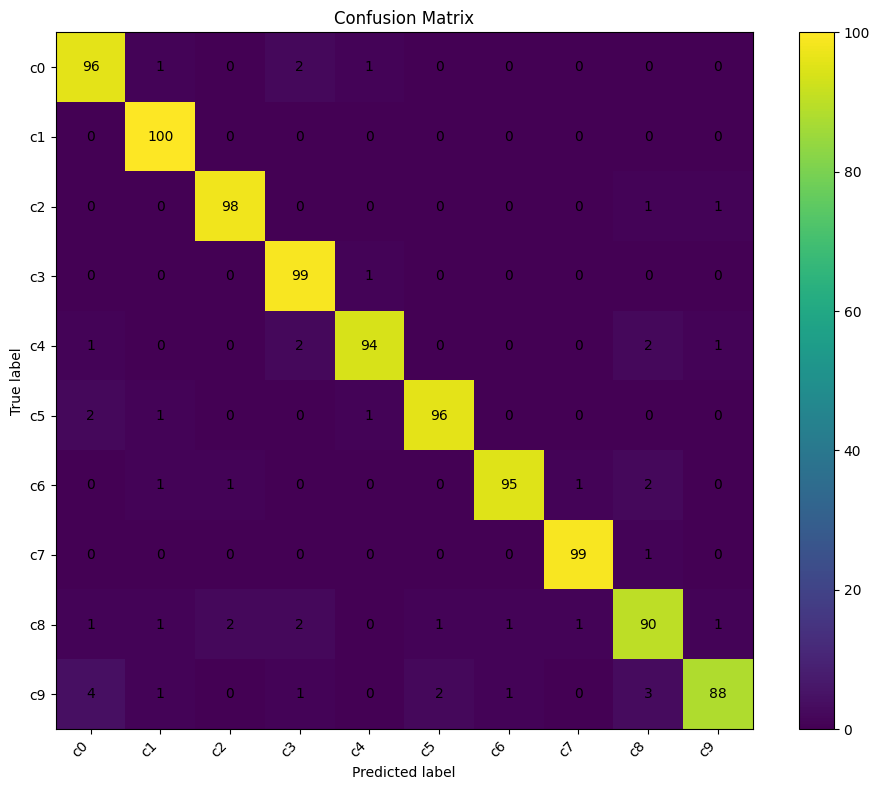

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)

plt.xticks(
    range(10),
    [f"c{i}" for i in range(10)],
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    [f"c{i}" for i in range(10)]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [27]:
def predict_driver_image(image_path, model, label_binarizer, class_names):

    image = cv2.imread(image_path)

    if image is None:
        print("Image not found.")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_resized = cv2.resize(image_rgb, (128, 128))

    image_array = image_resized.astype("float32")
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(
        image_array,
        verbose=0
    )[0]

    top_indices = np.argsort(prediction)[::-1][:3]

    predicted_index = top_indices[0]
    predicted_class = label_binarizer.classes_[predicted_index]

    print(f"Prediction: {class_names[predicted_class]}")
    print(f"Confidence: {prediction[predicted_index] * 100:.2f}%")

    print("\nTop-3:")

    for rank, index in enumerate(top_indices, 1):
        class_id = label_binarizer.classes_[index]

        print(
            f"{rank}. "
            f"{class_names[class_id]} "
            f"({prediction[index] * 100:.2f}%)"
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(
        f"{class_names[predicted_class]} - "
        f"{prediction[predicted_index] * 100:.2f}%"
    )
    plt.show()

Prediction: Reaching behind
Confidence: 94.08%

Top-3:
1. Reaching behind (94.08%)
2. Talking on phone - left hand (2.57%)
3. Texting - left hand (2.12%)


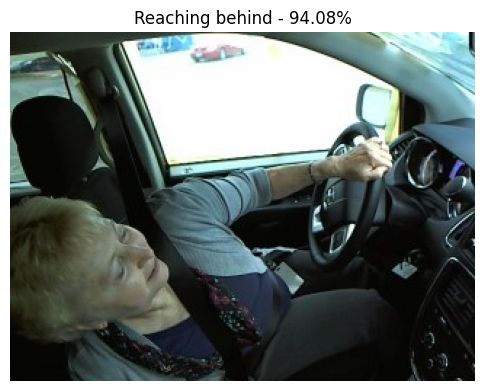

In [30]:
test_image_path = r"C:\Users\kara\Desktop\DL\driver_dataset\imgs\test\img_340.jpg"

predict_driver_image(
    test_image_path,
    best_model,
    label_binarizer,
    class_names
)